## Homework B3: Bangladesh: Effect of Surviving Children but with correlated features
By Prabhakar Srivastava

### B/c my PyMC was giving me errors had to update PyMC to run
### Step 1
sudo rm -rf /Library/Developer/CommandLineTools
sudo xcode-select --install

### Step 2
conda activate bap3
conda update --all -c conda-forge

### Step 3
pytensor-cache clear

### Step 4
echo "[global]\ncxx = /usr/bin/clang++" > ~/.pytensorrc


In [1]:
# Import libraries
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pymc as pm
import arviz as az
import pytensor.tensor as pt

In [2]:
# Random seed and plotting style
seed_ = sum(map(ord, "Homemwork B3 Correlated Random Variables"))
random_seed = default_rng(seed_)

az.style.use("arviz-doc")

Download the data

In [3]:
filepath_name:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/bangladesh.csv"
df = pd.read_csv(filepath_name, sep=";")
df.head()

,woman,district,use.contraception,living.children,age.centered,urban
0,1,1,0,4,18.4400,1
1,2,1,0,1,-5.5599,1
2,3,1,0,3,1.4400,1
3,4,1,0,4,8.4400,1
4,5,1,0,1,-13.5590,1


We know that one district is missing so we will be careful when creating coords!

In [4]:
# Build the Coords for PyMC

# Add a district id to data
df["district_id"] = df["district"].sub(1)

DISTRICTS = np.arange(0, df["district"].max())

# living.children will be an ordered effect
children_idx, CHILDREN = pd.factorize(df["living.children"], sort=True)

n_children = len(CHILDREN)
NVAR = int(3) # Because we want correlated effects for intercepts and 2 slopes

# Coordinates
COORDS = {
    "district": DISTRICTS,
    "children": CHILDREN,
    "variables": np.arange(NVAR),
    "obs": np.arange(len(df))
}

PyMC Model with Correlated Priors on Slope and Varying Districts <br>
<center> $C \sim Bernoulli(p)$ </center>
<center> $p = \text{invlogit}(\alpha_{D[i]} + \beta_{U_{D[i]}}U_i + \beta_{K_{D[i]}}K_{ordered} + \beta_A \cdot A)$ </center>
<center> $\alpha = \bar{\alpha} + \nu_{\_, 1}$ </center>
<center> $\beta_{U(K)} = \bar{\beta_{U(K)}} + \nu_{\_, 2(3)}$ </center>
<center> $\nu = (diag(\sigma)\textbf{L}\textbf{Z})^T$ </center>
<center> $Z_{j,k} \sim Normal(0, 1)$ </center>
<center> $\alpha, \beta \sim Normal(0,1)$</center>
<center> $\sigma \sim Exponential(1)$ </center>
<center> $R \sim LKJ(2)$</center>

In [5]:
with pm.Model(coords=COORDS) as model_corr:
    
    # Data Containers
    C = pm.Data("C", df["use.contraception"].values, dims="obs")
    U = pm.Data("U", df["urban"].values, dims="obs")
    district_id = pm.Data("district_id", df["district_id"].values, dims="obs")
    A = pm.Data("A", df["age.centered"].values, dims="obs")
    K = pm.Data("K", children_idx, dims="obs")

    # Priors
    # Ordered effect first: ordered effect of children
    η = pm.Dirichlet("η", pt.ones(n_children - 1))
    η_ordered = pt.concatenate([[0.], pt.cumsum(η)])

    # Age Prior
    β_age = pm.Normal("β_age", mu=0., sigma=0.25)

    # Non-centered parameterization: to the bar add the L times Z component: L is the LKJCholeskyCov
    α_bar = pm.Normal("α_bar", 0, 1) # Intercept
    β_U_bar = pm.Normal("β_U_bar", 0, 1)
    β_K_bar = pm.Normal("β_K_bar", 0, 1)

    σ_s = pm.Exponential.dist(1.0, shape=NVAR)

    # Cholesky Prior
    chol, corr, std = pm.LKJCholeskyCov("chol_cov", 
                                        n=NVAR, 
                                        eta=2, # Regularizing priors (lecture uses 4, i find 2 does better?)
                                        sd_dist=σ_s, 
                                        compute_corr=True)

    Z = pm.Normal("Z", 0, 1, dims=("variables", "district")) # Normal Variable with dimensions of variables and district
    L = pt.dot(chol, Z) # Should have dims of ("variables", "district")
    # print(L.shape.eval()) #<- Only used to verify the shape of variables

    # Coefficients for non-centered paremeterization
    α = α_bar + L[0, :]
    β_U = β_U_bar + L[1, :]
    β_K = β_K_bar + L[2, :]

    # Linear Regression coefficient: Age does not vary by district but rest do!
    μ = α[district_id] + β_age * A + β_U[district_id] * U + β_K[district_id] * η_ordered[K]
    p = pm.Deterministic("p", pm.math.invlogit(μ), dims="obs") # Save p in deterministic for use in trace output
    
    # Likelihood
    likelihood = pm.Bernoulli("likelihood", 
                              p = p,
                              observed = C,
                              dims = "obs"
                             )

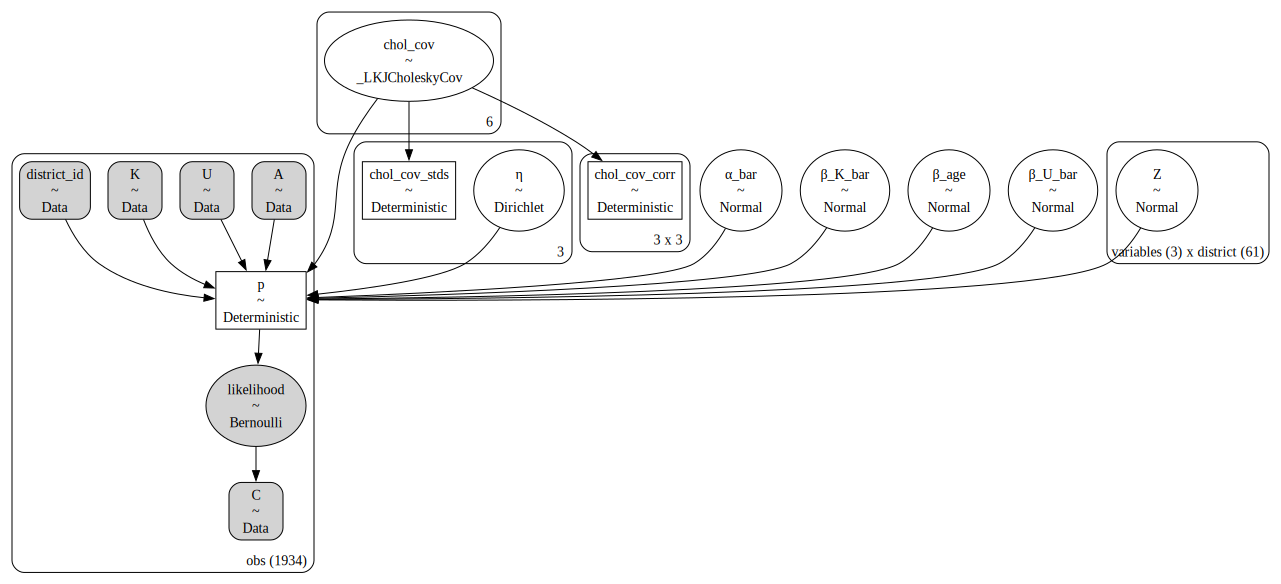

In [6]:
pm.model_to_graphviz(model_corr)

In [7]:
with model_corr:
    idata_corr = pm.sample(random_seed=random_seed)
    idata_corr.extend(
        pm.sample_posterior_predictive(
            idata_corr,
            random_seed=random_seed
        )
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [η, β_age, α_bar, β_U_bar, β_K_bar, chol_cov, Z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.
Sampling: [likelihood]


Output()

In [8]:
az.summary(idata_corr, round_to=2)

/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β_age,-0.03,0.01,-0.04,-0.01,0.00,0.00,3554.89,2664.84,1.0
α_bar,-1.66,0.16,-1.98,-1.36,0.00,0.00,2229.94,2195.65,1.0
β_U_bar,0.76,0.17,0.43,1.07,0.00,0.00,2600.12,2883.29,1.0
β_K_bar,1.35,0.18,1.01,1.68,0.00,0.00,2745.49,2708.79,1.0
"Z[0, 0]",-1.24,0.63,-2.51,-0.12,0.01,0.01,1908.99,2319.38,1.0
...,...,...,...,...,...,...,...,...,...
p[1929],0.21,0.06,0.10,0.32,0.00,0.00,3647.37,3155.43,1.0
p[1930],0.29,0.07,0.16,0.42,0.00,0.00,3890.63,3144.97,1.0
p[1931],0.21,0.06,0.10,0.32,0.00,0.00,3647.37,3155.43,1.0
p[1932],0.19,0.08,0.06,0.35,0.00,0.00,1587.06,2681.65,1.0


In [9]:
az.summary(idata_corr, var_names=["η"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
η[0],0.79,0.08,0.64,0.94,0.0,0.0,3034.36,2574.87,1.0
η[1],0.13,0.08,0.00,0.27,0.0,0.0,2076.88,1774.69,1.0
η[2],0.08,0.06,0.00,0.18,0.0,0.0,3059.91,2191.61,1.0


In [10]:
az.summary(idata_corr, var_names=["chol_cov_corr", "chol_cov_stds"])

/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"chol_cov_corr[0, 0]",1.000,0.000,1.000,1.000,0.000,NaN,4000.0,4000.0,NaN
"chol_cov_corr[0, 1]",-0.670,0.186,-0.942,-0.338,0.005,0.006,1306.0,1832.0,1.00
"chol_cov_corr[0, 2]",-0.395,0.342,-0.896,0.241,0.012,0.007,901.0,1595.0,1.00
"chol_cov_corr[1, 0]",-0.670,0.186,-0.942,-0.338,0.005,0.006,1306.0,1832.0,1.00
"chol_cov_corr[1, 1]",1.000,0.000,1.000,1.000,0.000,0.000,3522.0,3938.0,1.00
"chol_cov_corr[1, 2]",0.277,0.341,-0.416,0.824,0.009,0.006,1407.0,2276.0,1.00
"chol_cov_corr[2, 0]",-0.395,0.342,-0.896,0.241,0.012,0.007,901.0,1595.0,1.00
"chol_cov_corr[2, 1]",0.277,0.341,-0.416,0.824,0.009,0.006,1407.0,2276.0,1.00
"chol_cov_corr[2, 2]",1.000,0.000,1.000,1.000,0.000,0.000,3959.0,3951.0,1.00
chol_cov_stds[0],0.713,0.178,0.394,1.039,0.006,0.004,843.0,1384.0,1.01


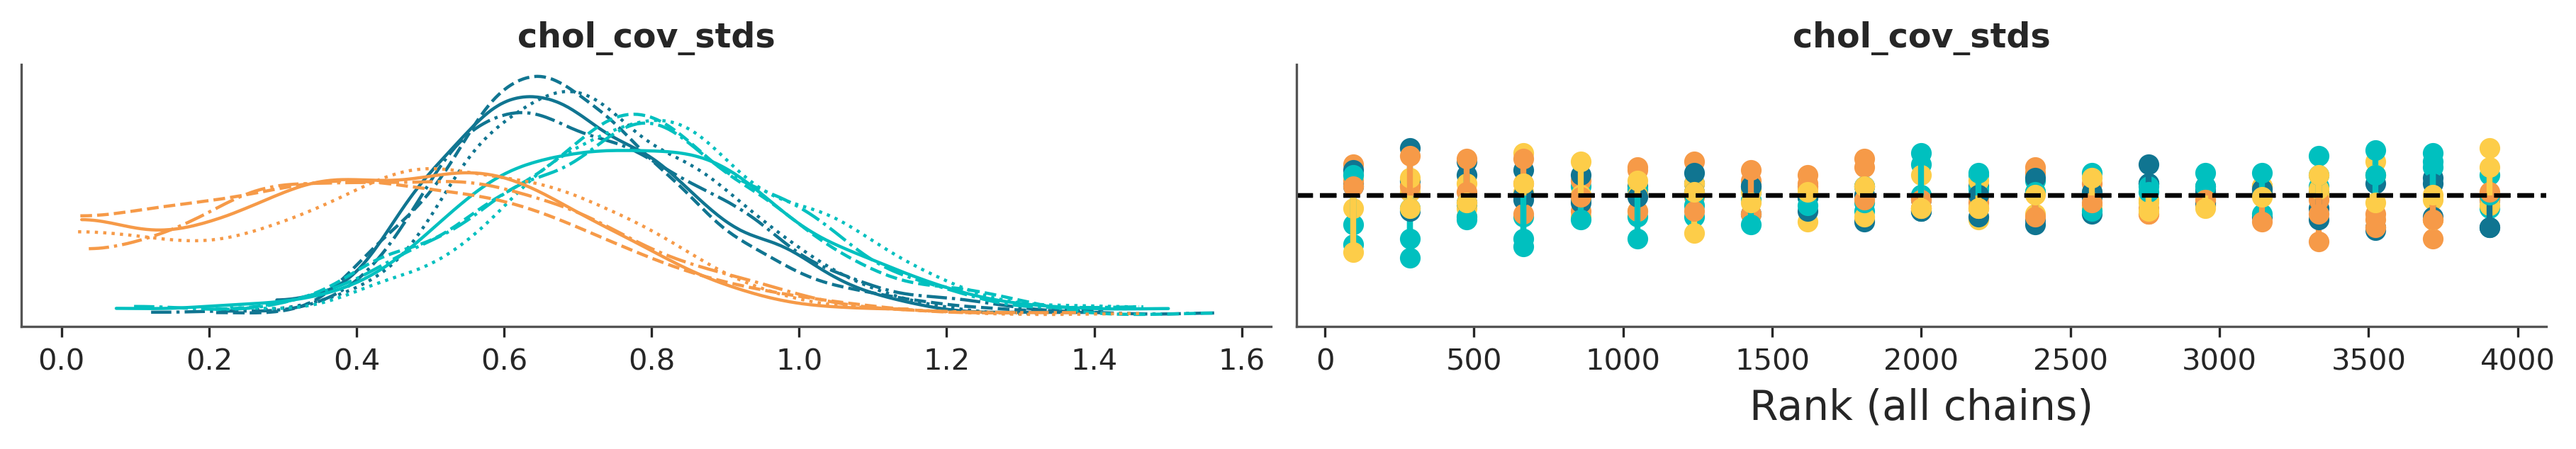

In [11]:
az.plot_trace(idata_corr, var_names = ["chol_cov_stds"], kind="rank_vlines")
plt.show()

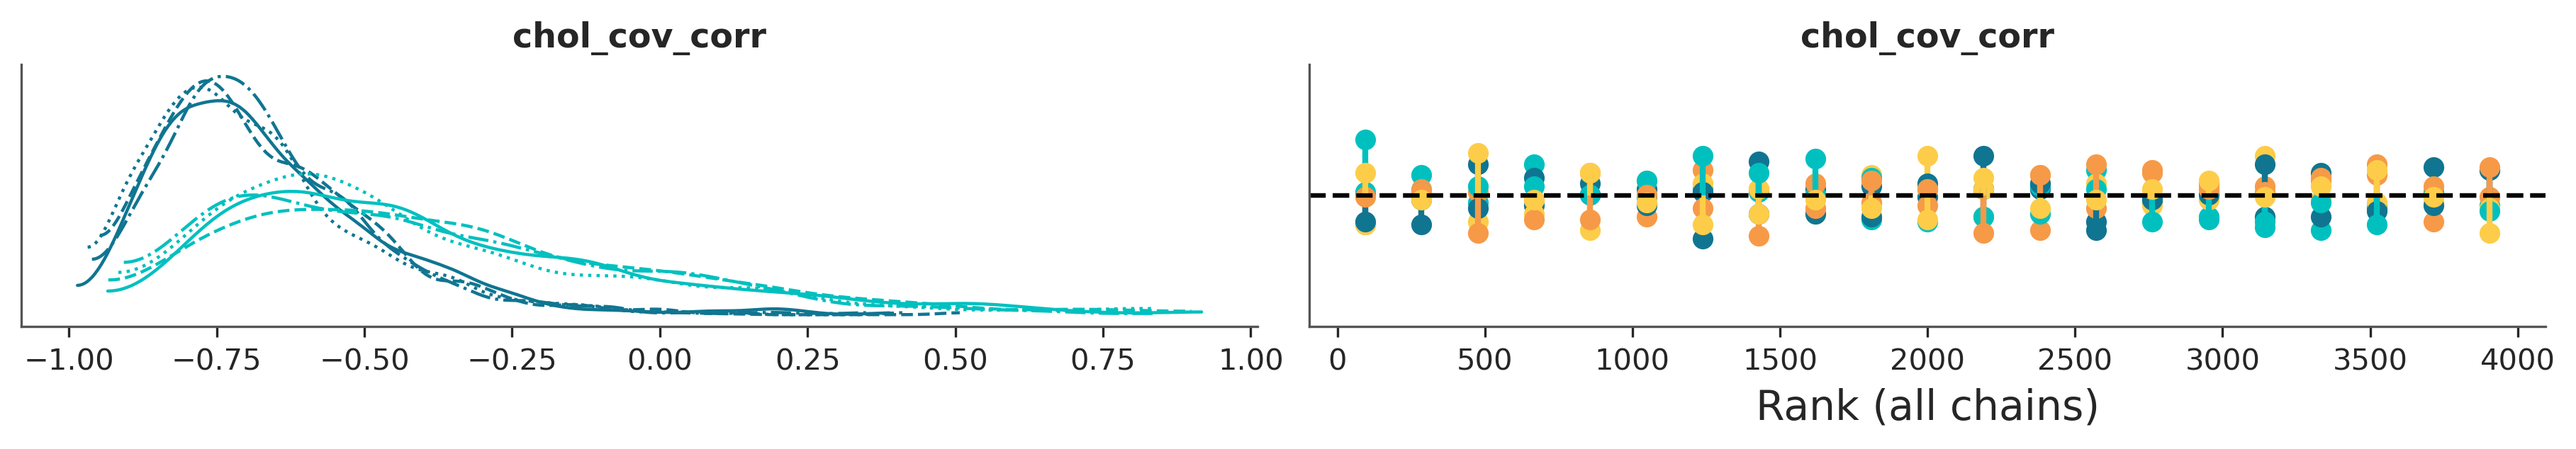

In [12]:
az.plot_trace(idata_corr, 
              var_names = ["chol_cov_corr"], 
              coords={"chol_cov_corr_dim_0": [0], "chol_cov_corr_dim_1": [1, 2]},
              kind="rank_vlines")
plt.show()

### Recreate Plot to show Contraception Probability by Rural/Urban Districts

In [13]:
# Create a district to urban mapping
district_to_urban_dict = {d: df[df["district_id"]==d]["urban"].max() 
                          for d in DISTRICTS 
                          if len(df[df["district_id"]==d]["urban"]) > 0
                         }

# Create a dataframe of lower, upper, and urban by districts
# Intialize a dict 
p_dict = {"district": [],
         "lower_hdi": [],
          "upper_hdi": [],
          "mean": [],
          "urban": []
         }

for d in district_to_urban_dict.keys():
    
    # District
    obs_idx = df[df["district_id"] == d].index.to_list()

    # compute highest density interval (HDI) at 94% which is default
    lower, higher = az.hdi(idata_corr.posterior["p"].sel(obs=obs_idx), input_core_dims=[["chain", "draw", "obs"]])["p"]
    mean = idata_corr.posterior["p"].sel(obs=obs_idx).mean(dim=("chain", "draw", "obs"))

    p_dict["district"].append(d + 1) # Note in dataset districts begin counting from 1 so add 1 back
    p_dict["lower_hdi"].append(lower.values)
    p_dict["upper_hdi"].append(higher.values)
    p_dict["mean"].append(mean.values)
    p_dict["urban"].append(district_to_urban_dict[d])

p_df = pd.DataFrame(p_dict)

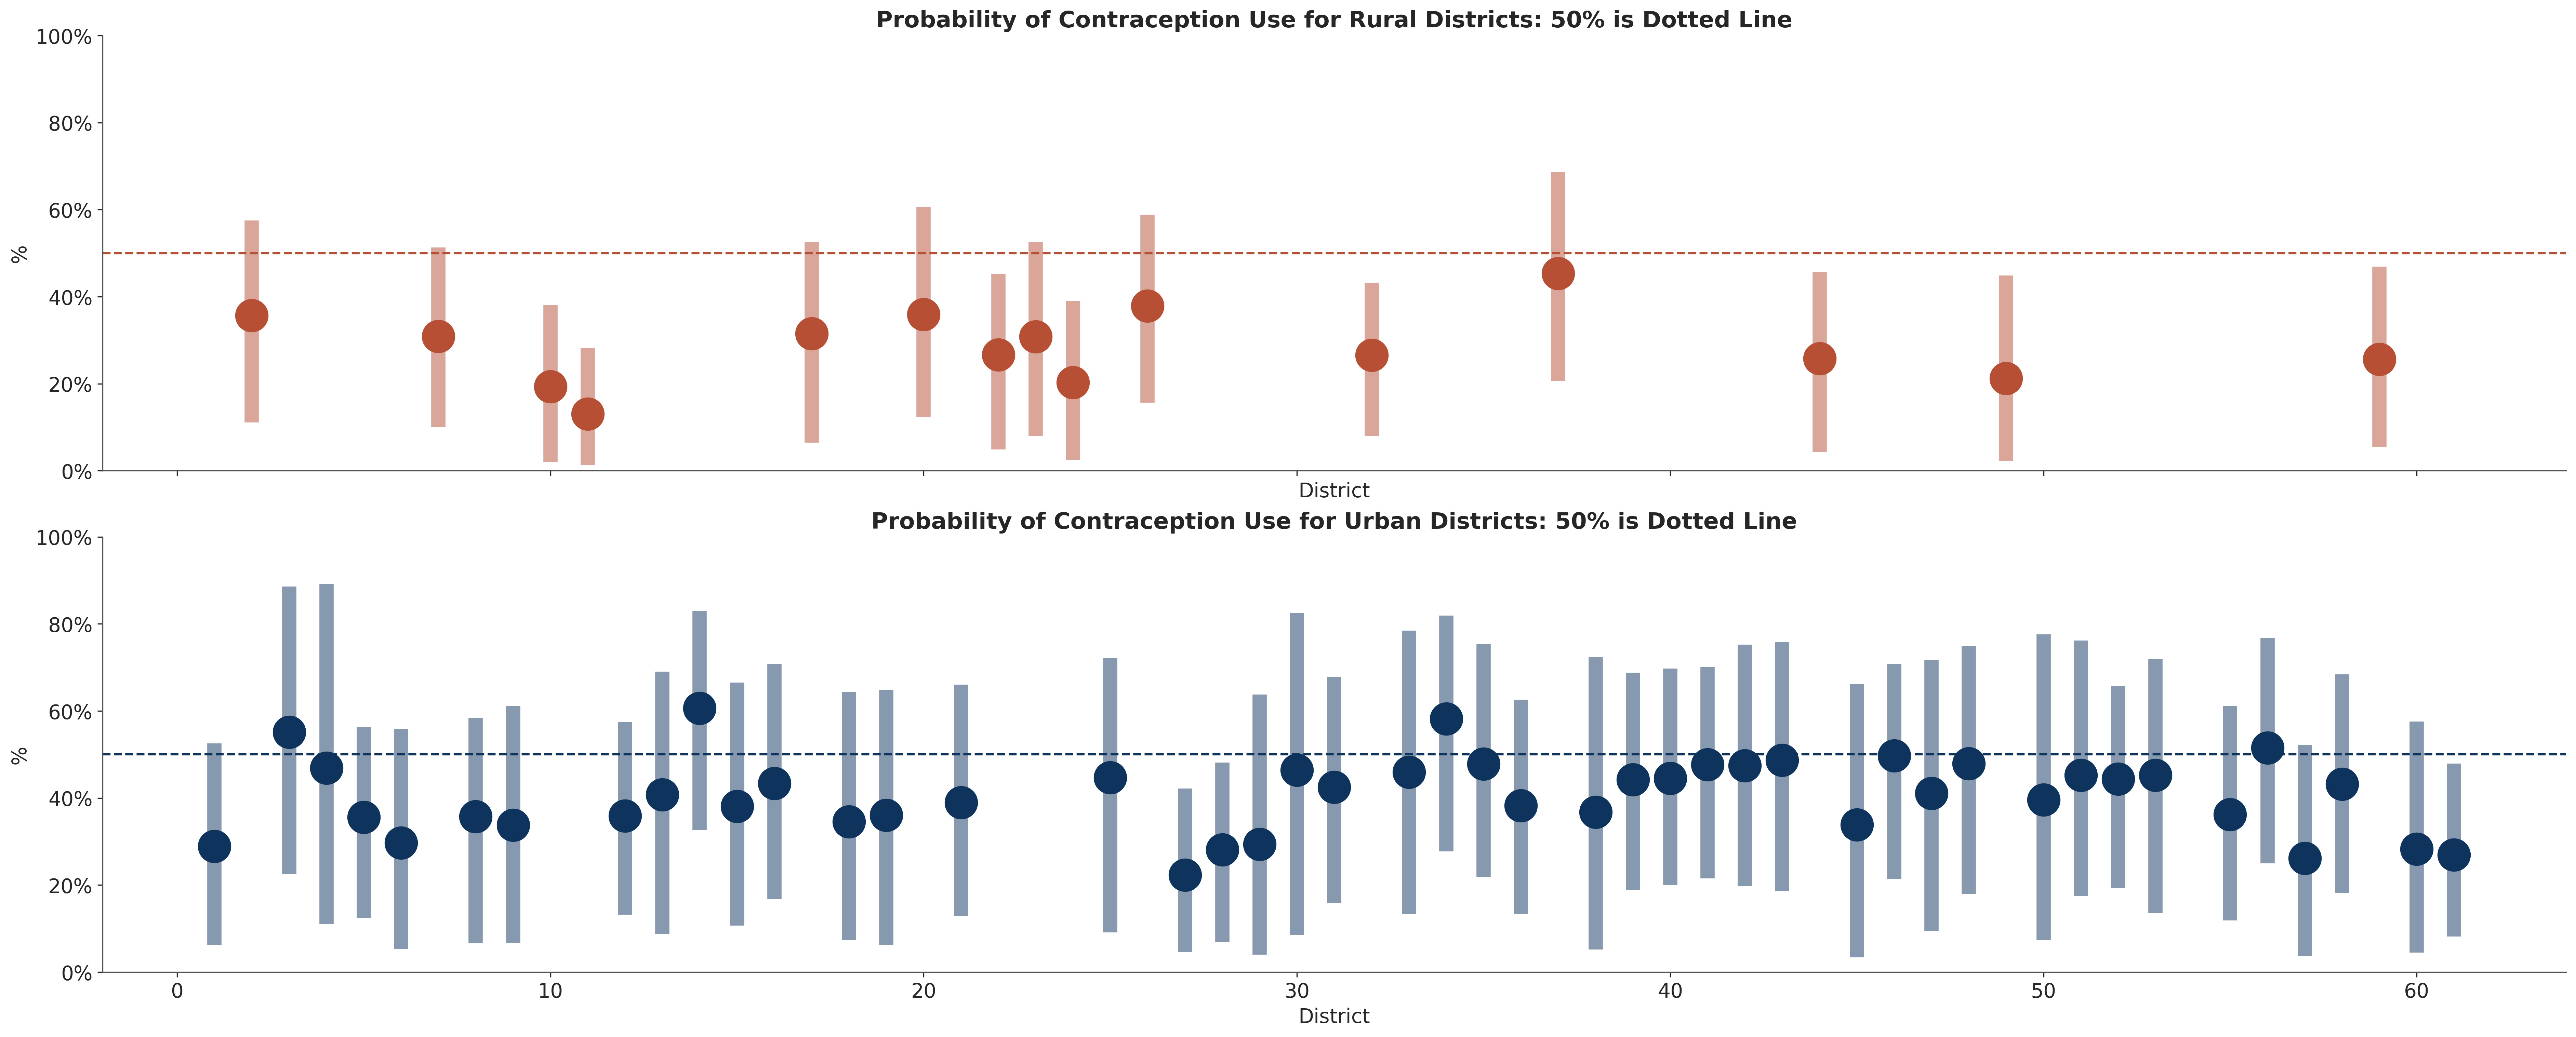

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(25, 10), sharex=True)
colors_p = ["#B74F35", "#0E345E"]

for i, u in enumerate(["rural", "urban"]):

    df_to_plot = p_df[p_df["urban"]==i]
    
    axes[i].vlines(x = df_to_plot["district"],
                   ymin = df_to_plot["lower_hdi"],
                   ymax = df_to_plot["upper_hdi"],
                   color = colors_p[i],
                   linewidth = 10,
                   alpha = 0.5
                  )
    
    axes[i].scatter(x = df_to_plot["district"],
                    y = df_to_plot["mean"],
                    s = 500,
                    color = colors_p[i]
                   )
    
    axes[i].axhline(0.5, ls="--", color=colors_p[i])
    axes[i].set_ylim([0., 1.])
    axes[i].yaxis.set_major_formatter(PercentFormatter(1.0))

    axes[i].set_xlabel("District")
    axes[i].set_ylabel("%")
    axes[i].set_title(f"Probability of Contraception Use for {u.title()} Districts: 50% is Dotted Line")

plt.show()